## 1 · Imports

In [2]:
from anndata import AnnData
from typing import Optional

# Libraries
import anndata as ad
import matplotlib as plt
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib.pyplot import rc_context
from scipy.stats import median_abs_deviation

from functools import partial
import altair as alt
import seaborn as sns
import decoupler as dc
from scipy.sparse import csr_matrix
import os
from pathlib import Path

import mudata as mu
import scanpy as sc
import scirpy as ir
import altair as alt
alt.data_transformers.enable("vegafusion")

import anndata as ad
import numpy as np
import palantir

import numpy as np
import scipy.sparse as sp


In [3]:
import muon as mu
from muon import MuData

2026-06-01 13:21:21.742607: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-01 13:21:21.796208: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 2 · Data Loading

Load mudata

In [3]:
mdata = mu.read_h5mu("/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/40_gex_surface_prot/002_annotate_mudata.h5mu")

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/anndata/utils.py:354: ExperimentalFeatureWarning: Support for Awkward Arrays is currently experimental. Behavior may change in the future. Please report any issues you may encounter!
  warnings.warn(msg, category, stacklevel=stacklevel)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adop

In [4]:
mdata

MuData object with n_obs × n_vars = 72592 × 17590
  3 modalities
    gex:	72592 x 17581
      obs:	'adata_name', 'condition', 'batch_id', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'rna_leiden', 'rna_leiden_05', 'gex03', 'group4', 'cell_annotation_05'
      var:	'gene_ids', 'feature_types', 'mito', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'n_cells'
      uns:	'cell_annotation_05_colors', 'gex03', 'gex03_colors', 'group4_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'rna_leiden', 'rna_leiden_05', 'rna_leiden_05_colors', 'rna_leiden_colors', 'sample_id_colors', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    adt:	56305 x 9
      obs:	'sample_id', 'year', 'tissue', 'treatment', 'received_ici'
    airr:	56305 x 0
      obs:	'sample_id'
      obsm:	'airr'

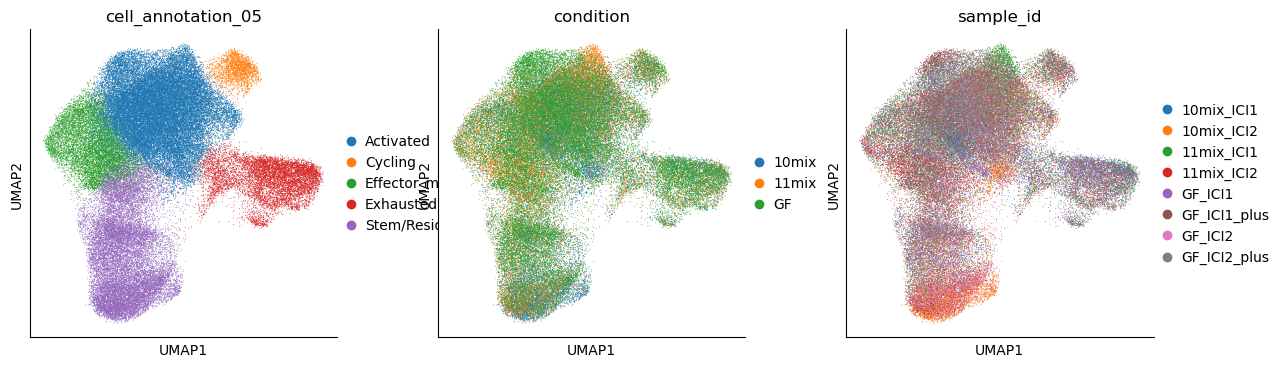

In [5]:
sc.pl.umap(mdata["gex"], color=["cell_annotation_05", "condition", "sample_id"])

## 3 · PAGA



In [6]:
sc.tl.draw_graph(mdata["gex"])

Package 'fa2-modified' is not installed, falling back to layout 'fr'.To use the faster and better ForceAtlas2 layout, install package 'fa2-modified' (`pip install fa2-modified`).


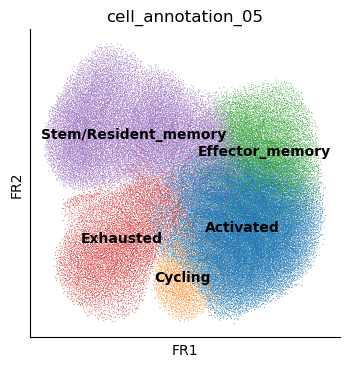

In [7]:
sc.pl.draw_graph(mdata["gex"], color="cell_annotation_05", legend_loc="on data")

In [12]:
sc.tl.paga(mdata["gex"], groups="cell_annotation_05")

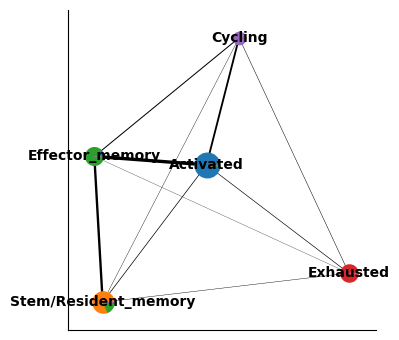

In [13]:
sc.pl.paga(mdata["gex"], color=["gex03"])

In [15]:
mdata.update()

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [16]:
mdata

MuData object with n_obs × n_vars = 72592 × 17590
  3 modalities
    gex:	72592 x 17581
      obs:	'adata_name', 'condition', 'batch_id', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'rna_leiden', 'rna_leiden_05', 'gex03', 'group4', 'cell_annotation_05'
      var:	'gene_ids', 'feature_types', 'mito', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'n_cells'
      uns:	'cell_annotation_05_colors', 'gex03', 'gex03_colors', 'group4_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'rna_leiden', 'rna_leiden_05', 'rna_leiden_05_colors', 'rna_leiden_colors', 'sample_id_colors', 'umap', 'condition_colors', 'draw_graph', 'paga', 'cell_annotation_05_sizes'
      obsm:	'X_pca', 'X_umap', 'X_draw_graph_fr'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    adt:	56305 x 9
      obs:	'sample_id', 'year', 'tissue', 'treatment', 'received_ici'
    airr:	56305 x 0
      obs:	'sample_id'
      obsm:	'airr'

## 3 · Pseudotime



In [6]:
root_celltype = "Stem/Resident_memory"

#sc.pp.neighbors(mdata["gex"], use_rep="X_pca")
#sc.tl.diffmap(mdata["gex"])
#sc.pp.neighbors(mdata["gex"], use_rep="X_diffmap")

iroot = np.flatnonzero(mdata["gex"].obs["cell_annotation_05"] == root_celltype)[0]
mdata["gex"].uns["iroot"] = iroot
sc.tl.dpt(mdata["gex"])

Trying to run `tl.dpt` without prior call of `tl.diffmap`. Falling back to `tl.diffmap` with default parameters.


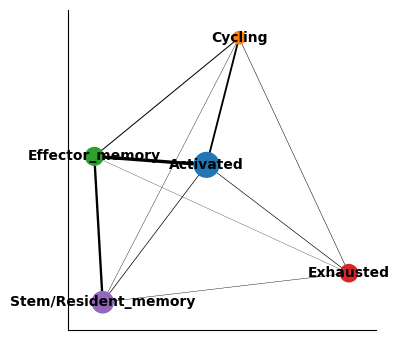

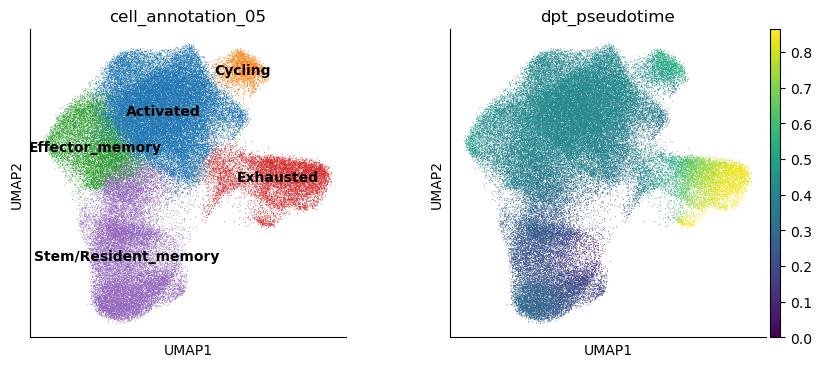

In [7]:
sc.pl.paga(mdata["gex"], color=["cell_annotation_05"])
sc.pl.umap(mdata["gex"], color=["cell_annotation_05", "dpt_pseudotime"], legend_loc="on data", cmap = "viridis", vmax="p99")

In [8]:
mdata.update()

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [9]:
mdata

MuData object with n_obs × n_vars = 72592 × 17590
  3 modalities
    gex:	72592 x 17581
      obs:	'adata_name', 'condition', 'batch_id', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'rna_leiden', 'rna_leiden_05', 'gex03', 'group4', 'cell_annotation_05', 'dpt_pseudotime'
      var:	'gene_ids', 'feature_types', 'mito', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'n_cells'
      uns:	'cell_annotation_05_colors', 'cell_annotation_05_sizes', 'condition_colors', 'draw_graph', 'gex03', 'gex03_colors', 'group4_colors', 'hvg', 'log1p', 'neighbors', 'paga', 'pca', 'rna_leiden', 'rna_leiden_05', 'rna_leiden_05_colors', 'rna_leiden_colors', 'sample_id_colors', 'umap', 'iroot', 'diffmap_evals'
      obsm:	'X_draw_graph_fr', 'X_pca', 'X_umap', 'X_diffmap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    adt:	56305 x 9
      obs:	'sample_id', 'year', 'tissue', 'treatment', 'received_ici'
    airr:	56305 x 0
      obs:	'sample_id'
      obsm:	'airr'

In [10]:
#mdata.write_h5mu("/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/40_gex_surface_prot/003_trajectory_annotated_mudata.h5mu")

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
